# Post-process trip data

## Install and import packages

In [1]:
#!pip install --upgrade seaborn
!pip install plotly

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

## Utils

In [3]:
# Set SAVE equals to True, in order to Save cleaned trip data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [4]:
# Load trip data
#######trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 1200
trip_data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             1150 non-null   int64  
 1   charge_mode       1150 non-null   int64  
 2   duration_minutes  1150 non-null   float64
 3   km_driven         1150 non-null   float64
 4   charge            1150 non-null   float64
 5   id                1150 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 54.0 KB


In [5]:
trip_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,0,0,48.794883,8.319159,0.953412,1
1,0,0,32.129596,7.589486,0.376242,2
2,0,0,31.166082,12.847598,-1.207842,3
3,0,0,36.505525,18.078372,-3.260641,4
4,0,0,36.705881,6.445220,0.190205,5
5,0,0,119.056725,95.565874,-20.588643,6
6,0,0,161.162709,145.432918,-26.493321,7
7,0,0,49.309033,7.796381,-1.256221,8
8,0,0,60.231676,17.914068,-1.674766,9
9,0,0,110.791397,7.971167,2.820374,10


### Data description

In [6]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [7]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    print("\n🔍 Records with missing values:\n")
    print(records_with_nan.head(length))

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|


In [8]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,1150.0,44.963528,48.223917,3.252129,10.783979,21.911608,63.494532,205.864550
delta_soc,1150.0,-7.890895,9.503303,-32.547265,-14.473106,-4.125130,-0.529188,5.588075


In [9]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

📊 Statistics on driven km:
 count    1150.000000
mean       44.963528
std        48.223917
min         3.252129
25%        10.783979
50%        21.911608
75%        63.494532
max       205.864550
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    1150.000000
mean        7.890895
std         9.503303
min        -5.588075
25%         0.529188
50%         4.125130
75%        14.473106
max        32.547265
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    1150.000000
mean       27.625177
std        14.469235
min         1.393898
25%        17.015943
50%        27.238886
75%        39.065377
max        63.113774
Name: avg_speed, dtype: float64
99th percentile of average speed: 55.13 km/h

🛢️ Statistics on km per percentage of battery:
 count    1150.000000
mean        6.979356
std        52.178297
min      -624.342402
25%         4.102303
50%         5.054498
75%         6.464739
max       759.894407
Name: km_per_

### Identify and remove anomalous records

In [10]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of snapshot records: 0


In [11]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [12]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of records with negative duration: 0


In [13]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [14]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
if length > 0:
    stationary_records.head(length)

Number of stationary records: 0


In [15]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [16]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 116


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
9,0,0,110.791397,7.971167,2.820374,10,2.820374,-2.820374,4.316852,-2.826281,-0.353822
10,0,0,60.609952,5.202307,1.489698,11,1.489698,-1.489698,5.149953,-3.492190,-0.286353
12,0,0,89.655400,4.280131,3.834566,14,3.834566,-3.834566,2.864388,-1.116197,-0.895899
15,0,0,30.960472,9.188990,1.146293,22,1.146293,-1.146293,17.807848,-8.016264,-0.124746
28,0,0,65.755918,5.964139,1.631194,41,1.631194,-1.631194,5.442070,-3.656302,-0.273500
...,...,...,...,...,...,...,...,...,...,...,...
1101,0,0,61.542724,4.423924,1.546345,1675,1.546345,-1.546345,4.313027,-2.860891,-0.349541
1121,0,0,80.230707,5.318338,1.422234,1705,1.422234,-1.422234,3.977284,-3.739425,-0.267421
1131,0,0,56.622347,7.251322,2.171252,1721,2.171252,-2.171252,7.683880,-3.339696,-0.299428
1142,0,0,61.953881,6.785957,1.643143,1737,1.643143,-1.643143,6.571943,-4.129863,-0.242139


In [17]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [18]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
if length > 0:
    anomalous_movement_records.head(length)

Number of anomalous movement records: 0


In [19]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [20]:
# Identify records with high average speed 
#######################
SPEED_THRESHOLD = 130 #
#######################

anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]

length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [21]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [22]:
# Identify anomalous records with high discharge per km
############################
MAX_DISCHARGE_PER_KM = 0.9 #
############################

anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [23]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [24]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 76


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
87,0,0,75.121597,15.852556,-0.020862,139,-0.020862,0.020862,12.661517,759.894407,0.001316
1015,0,0,34.054139,5.103216,-0.007106,1716,-0.007106,0.007106,8.991357,718.185941,0.001392
300,0,0,37.125955,9.343923,-0.015982,511,-0.015982,0.015982,15.100901,584.651500,0.001710
204,0,0,42.662429,10.356904,-0.026807,341,-0.026807,0.026807,14.565842,386.353053,0.002588
147,0,0,34.938439,9.746685,-0.028789,243,-0.028789,0.028789,16.738044,338.560492,0.002954
...,...,...,...,...,...,...,...,...,...,...,...
439,0,0,36.677146,12.679337,-0.588714,762,-0.588714,0.588714,20.742077,21.537350,0.046431
280,0,0,32.031737,9.419346,-0.446701,466,-0.446701,0.446701,17.643775,21.086476,0.047424
435,0,0,30.262549,6.504540,-0.310400,755,-0.310400,0.310400,12.896217,20.955352,0.047721
417,0,0,92.865536,13.410552,-0.646868,720,-0.646868,0.646868,8.664497,20.731513,0.048236


In [25]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [26]:
# Identify anomalous records with low km per percentage of battery discharge 
############################
MIN_KM_PER_DISCHARGE = -10 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 77


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
208,0,0,68.747971,7.615418,0.723985,382,0.723985,-0.723985,6.646379,-10.518757,-0.095068
643,0,0,52.884855,5.194816,0.486938,1183,0.486938,-0.486938,5.893728,-10.668328,-0.093735
227,0,0,49.275717,6.119763,0.560522,407,0.560522,-0.560522,7.451658,-10.917975,-0.091592
687,0,0,51.796110,6.669075,0.609625,1251,0.609625,-0.609625,7.725377,-10.939639,-0.091411
398,0,0,93.768433,10.870517,0.961414,749,0.961414,-0.961414,6.955763,-11.306800,-0.088442
...,...,...,...,...,...,...,...,...,...,...,...
264,0,0,32.067700,10.079083,0.066578,485,0.066578,-0.066578,18.858383,-151.387874,-0.006606
606,0,0,69.293117,17.265897,0.090084,1110,0.090084,-0.090084,14.950313,-191.663682,-0.005217
442,0,0,28.250824,8.250131,0.024578,834,0.024578,-0.024578,17.521892,-335.676129,-0.002979
550,0,0,40.068157,13.938594,0.032705,1012,0.032705,-0.032705,20.872326,-426.197002,-0.002346


In [27]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [28]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   881 non-null    int64  
 1   charge_mode             881 non-null    int64  
 2   duration_minutes        881 non-null    float64
 3   km_driven               881 non-null    float64
 4   charge                  881 non-null    float64
 5   id                      881 non-null    int64  
 6   delta_soc               881 non-null    float64
 7   discharge               881 non-null    float64
 8   avg_speed               881 non-null    float64
 9   km_per_perc_of_battery  881 non-null    float64
 10  discharge_per_km        881 non-null    float64
dtypes: float64(8), int64(3)
memory usage: 75.8 KB


In [29]:
# Print statistics
print('Statistics after post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

📊 Statistics on driven km:
 count    881.000000
mean      56.272938
std       49.861859
min        4.304481
25%       17.929960
50%       33.979409
75%       87.487729
max      205.864550
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    881.000000
mean      10.684142
std        9.149678
min       -0.999276
25%        2.833652
50%        7.918173
75%       18.090379
max       32.547265
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    881.000000
mean      32.998270
std       11.748130
min        4.333661
25%       24.002565
50%       32.204663
75%       42.827577
max       63.113774
Name: avg_speed, dtype: float64
99th percentile of average speed: 55.48 km/h

🛢️ Statistics on km per percentage of battery:
 count    881.000000
mean       5.970913
std        3.513155
min       -9.516465
25%        4.520787
50%        5.245282
75%        6.385696
max       19.856374
Name: km_per_perc_of_battery, dtype: float64



## Data Visualization and Comparative Analysis

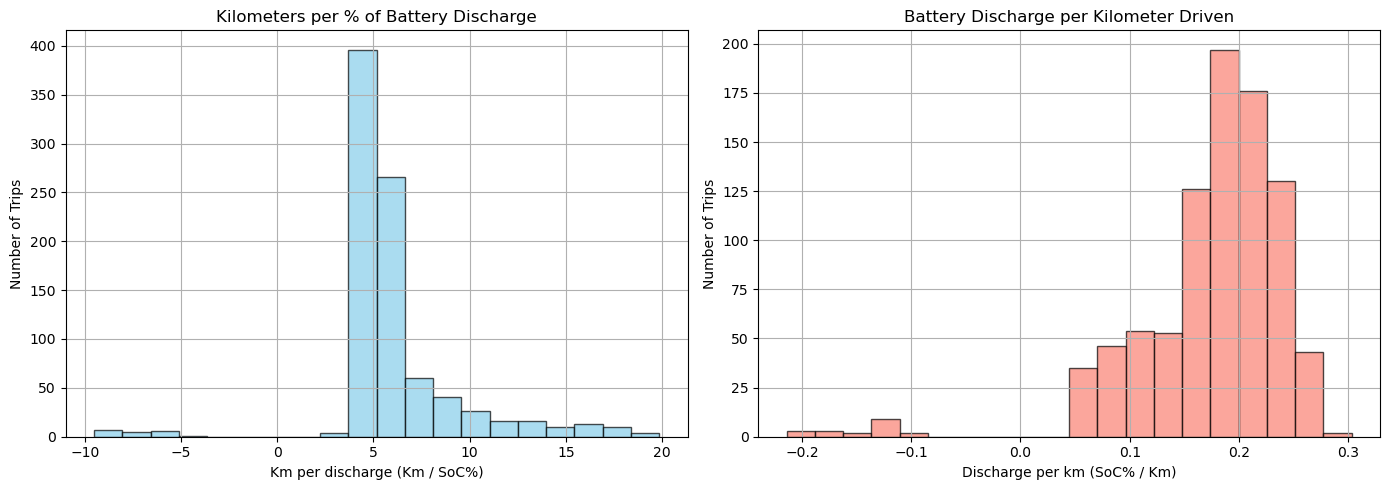

In [30]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [31]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,48.794883,8.319159,0.953412,1,0.953412,-0.953412,10.229547,-8.725670,-0.114604
1,0,0,31.166082,12.847598,-1.207842,3,-1.207842,1.207842,24.733808,10.636816,0.094013
2,0,0,36.505525,18.078372,-3.260641,4,-3.260641,3.260641,29.713373,5.544423,0.180361
3,0,0,119.056725,95.565874,-20.588643,6,-20.588643,20.588643,48.161517,4.641679,0.215439
4,0,0,161.162709,145.432918,-26.493321,7,-26.493321,26.493321,54.143884,5.489418,0.182169


In [32]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Record with maximum Km/SoC driven:\n")
max_km_row.head()


 Record with maximum Km/SoC driven:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
307,0,0,54.94935,17.499751,-0.881317,620,-0.881317,0.881317,19.108234,19.856374,0.050362


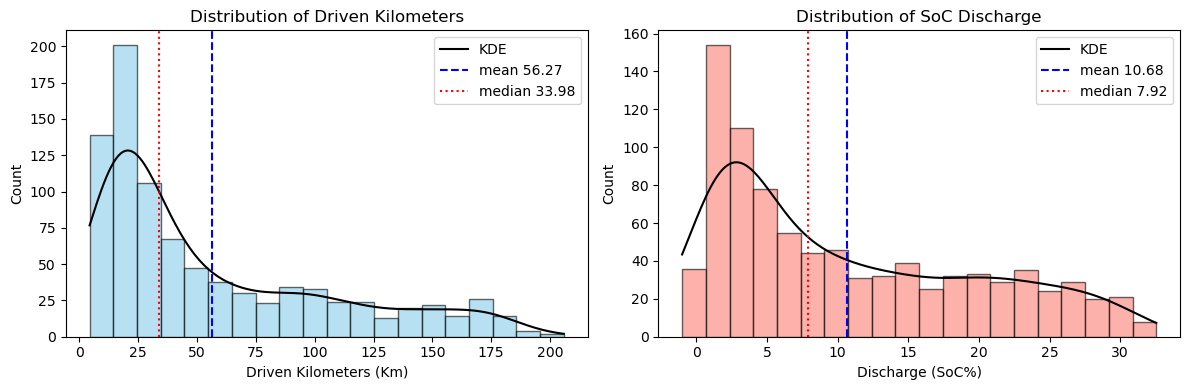

In [33]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()

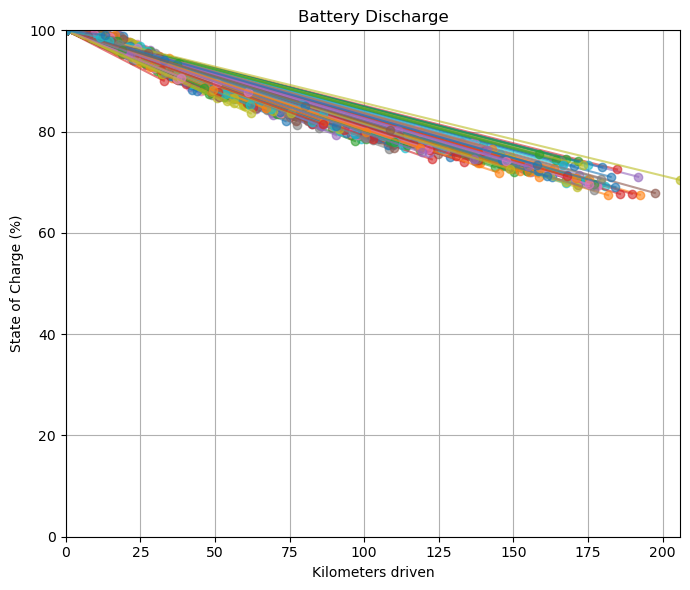

In [34]:
#######################################################
#Visualize delta_soc
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge'] 


# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


In [35]:
trip_data['discharge_per_km'].describe()

count    881.000000
mean       0.174569
std        0.069718
min       -0.214034
25%        0.151853
50%        0.188438
75%        0.218404
max        0.303254
Name: discharge_per_km, dtype: float64

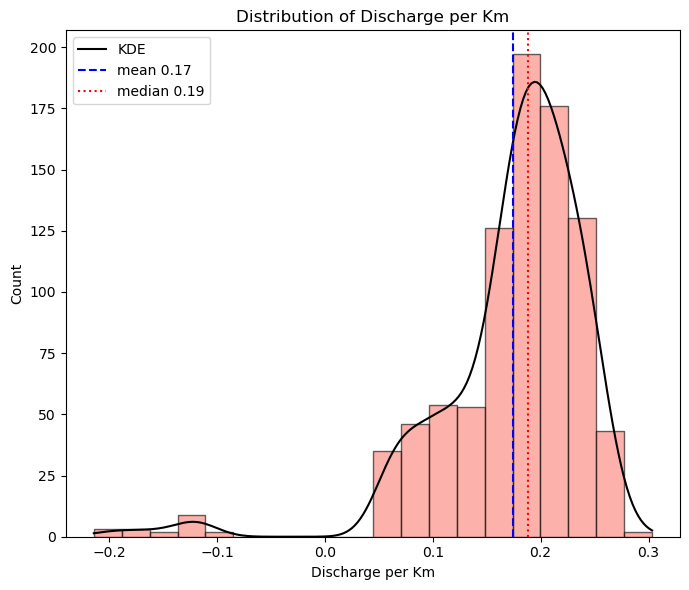

In [36]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='salmon', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

## Original dataset

In [37]:
trip_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1207 non-null   float64
 1   timestamp    1207 non-null   object 
 2   end_time     1207 non-null   object 
 3   odo          1207 non-null   float64
 4   end_odo      1207 non-null   float64
 5   soc          1207 non-null   float64
 6   end_soc      1207 non-null   float64
 7   event        1207 non-null   object 
 8   charge_mode  1207 non-null   object 
dtypes: float64(5), object(4)
memory usage: 85.0+ KB


In [38]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1134
📊 Statistics on driven km:
 count    1134.000000
mean       41.036223
std        46.765638
min         0.000000
25%         8.171871
50%        20.304685
75%        64.996092
max       378.187500
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    1134.000000
mean        7.874339
std         9.234552
min        -0.400000
25%         1.200000
50%         3.600000
75%        12.900000
max        74.600000
Name: discharge, dtype: float64


In [39]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [40]:
MAX_DISCHARGE_PER_KM = 0.9
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 7


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446
788,-2.471740e+18,2021-08-10 15:06:00,2021-08-10 15:08:00,31879.125000,31879.32813,36.0,35.6,trip,0,0.203130,0.4,0.507825,1.969182


In [41]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)



Number of anomalous discharge records: 3


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
535,-2.471740e+18,2021-07-23 00:31:00,2021-07-23 01:14:00,25236.45313,25248.85123,60.0,59.6,trip,0,12.3981,0.4,30.99525,0.032263
596,-2.471740e+18,2021-07-29 20:46:00,2021-07-29 21:00:00,27163.21875,27172.03125,15.2,14.9,trip,0,8.8125,0.3,29.37500,0.034043
521,-2.471740e+18,2021-07-13 00:08:00,2021-07-13 00:21:00,21541.39063,21550.70313,47.8,47.4,trip,0,9.3125,0.4,23.28125,0.042953


In [42]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1127 non-null   float64
 1   timestamp               1127 non-null   object 
 2   end_time                1127 non-null   object 
 3   odo                     1127 non-null   float64
 4   end_odo                 1127 non-null   float64
 5   soc                     1127 non-null   float64
 6   end_soc                 1127 non-null   float64
 7   event                   1127 non-null   object 
 8   charge_mode             1127 non-null   object 
 9   km_driven               1127 non-null   float64
 10  discharge               1127 non-null   float64
 11  km_per_perc_of_battery  1127 non-null   float64
 12  discharge_per_km        1127 non-null   float64
dtypes: float64(9), object(4)
memory usage: 114.6+ KB


In [43]:
trip_data_original['discharge_per_km'].describe()

count    1127.000000
mean        0.171472
std         0.081386
min        -0.474074
25%         0.151256
50%         0.182416
75%         0.205175
max         0.752941
Name: discharge_per_km, dtype: float64

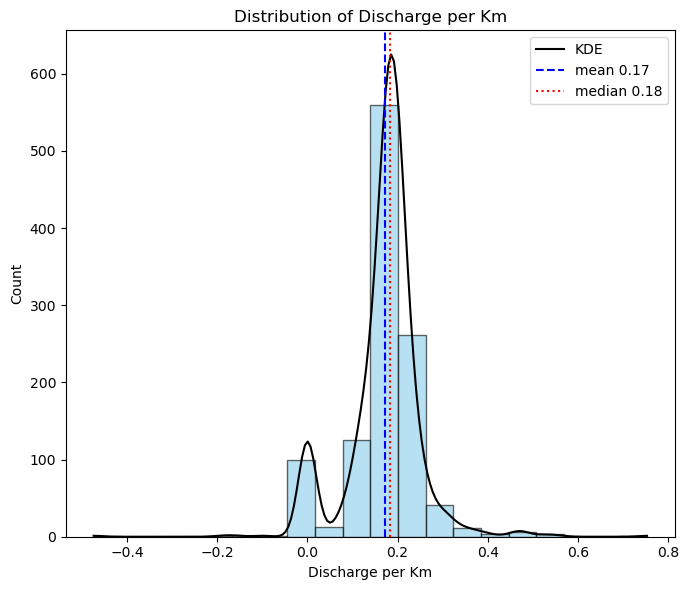

In [44]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

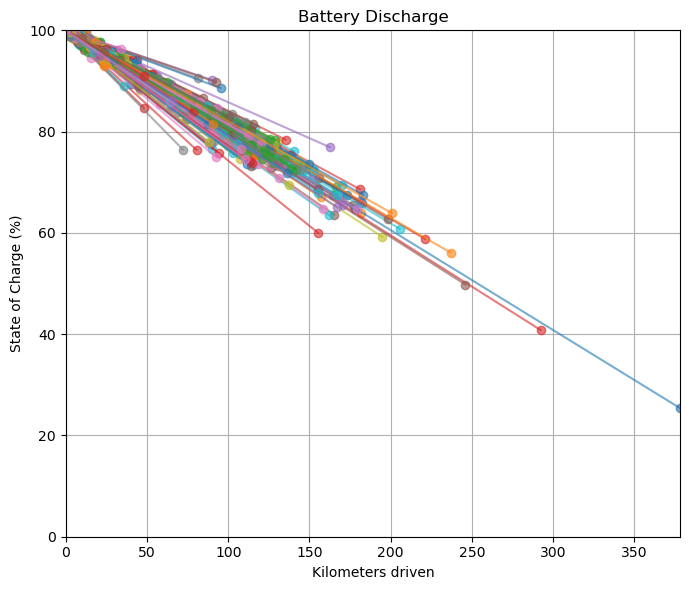

In [45]:
#######################################################
#visualiza delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Save trip data cleaned

In [46]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_path_csv, index=False)

In [47]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,48.794883,8.319159,0.953412,1,0.953412,-0.953412,10.229547,-8.725670,-0.114604,100,100.953412
1,0,0,31.166082,12.847598,-1.207842,3,-1.207842,1.207842,24.733808,10.636816,0.094013,100,98.792158
2,0,0,36.505525,18.078372,-3.260641,4,-3.260641,3.260641,29.713373,5.544423,0.180361,100,96.739359
3,0,0,119.056725,95.565874,-20.588643,6,-20.588643,20.588643,48.161517,4.641679,0.215439,100,79.411357
4,0,0,161.162709,145.432918,-26.493321,7,-26.493321,26.493321,54.143884,5.489418,0.182169,100,73.506679


In [48]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   881 non-null    int64  
 1   charge_mode             881 non-null    int64  
 2   duration_minutes        881 non-null    float64
 3   km_driven               881 non-null    float64
 4   charge                  881 non-null    float64
 5   id                      881 non-null    int64  
 6   delta_soc               881 non-null    float64
 7   discharge               881 non-null    float64
 8   avg_speed               881 non-null    float64
 9   km_per_perc_of_battery  881 non-null    float64
 10  discharge_per_km        881 non-null    float64
 11  soc                     881 non-null    int64  
 12  end_soc                 881 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 89.6 KB
